In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import my_linear_regression
import my_regularization
import importlib
importlib.reload(my_linear_regression)
importlib.reload(my_regularization)

from my_linear_regression import LinearRegression
from my_regularization import Regularization
lin = LinearRegression()
reg = Regularization()

In [84]:
df = pd.read_csv('data/house_prices/train.csv').set_index('Id')

df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [86]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [87]:
null_pct = df.loc[:, (df.isnull().sum() / len(df) > 0.5)].columns
null_pct

Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='str')

In [88]:
df.drop(columns=null_pct, inplace=True)

In [89]:
df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() == 1)].columns

C:\Users\Seif Adin\AppData\Local\Temp\ipykernel_12948\3387887208.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() == 1)].columns
C:\Users\Seif Adin\AppData\Local\Temp\ipykernel_12948\3387887208.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See ht

Index([], dtype='str')

In [90]:
df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() > 30)].columns

C:\Users\Seif Adin\AppData\Local\Temp\ipykernel_12948\395922782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').loc[:, (df.select_dtypes('object').nunique() > 30)].columns
C:\Users\Seif Adin\AppData\Local\Temp\ipykernel_12948\395922782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See http

Index([], dtype='str')

In [91]:
corr = df.corr(numeric_only=True).abs()
corr['SalePrice'].head()

MSSubClass     0.084284
LotFrontage    0.351799
LotArea        0.263843
OverallQual    0.790982
OverallCond    0.077856
Name: SalePrice, dtype: float64

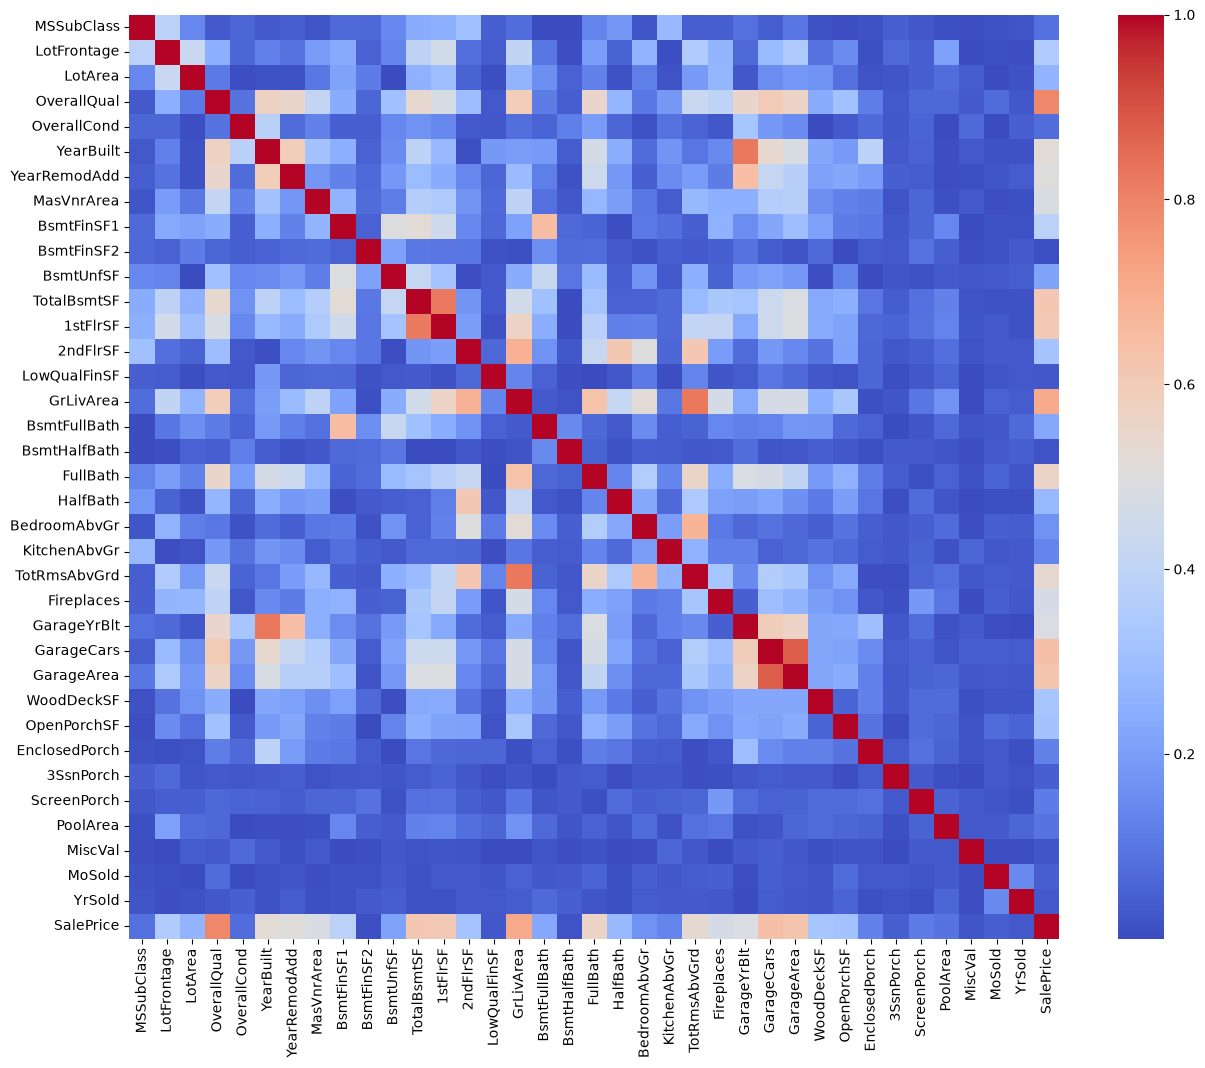

In [92]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm');

In [93]:
multi_col = ['BsmtUnfSF', 'GarageCars']
df.drop(columns=multi_col, inplace=True)

In [94]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn import set_config
set_config('display')

In [95]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimato

In [96]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('onehotencoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive es

In [97]:
preprocessing = ColumnTransformer([
    ('num', num_pipeline, df.drop('SalePrice', axis=1).select_dtypes('number').columns),
    ('cat', cat_pipeline, df.select_dtypes('object').columns),
    ], remainder='drop')

preprocessing

C:\Users\Seif Adin\AppData\Local\Temp\ipykernel_12948\944061423.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ('cat', cat_pipeline, df.select_dtypes('object').columns),


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [98]:
train_data = pd.read_csv('data/house_prices/train.csv').set_index('Id')
test_data = pd.read_csv('data/house_prices/test.csv').set_index('Id')

In [99]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [100]:
X = train_data.drop('SalePrice', axis=1)
y = train_data['SalePrice']

In [101]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=X['OverallQual'], random_state=42)

In [102]:
f'RMSE baseline = {root_mean_squared_error(y_val, [y.mean()] * len(y_val))}'

'RMSE baseline = 92498.93725001377'

In [103]:
X_train_preprocessed = preprocessing.fit_transform(X_train).toarray()
X_val_preprocessed = preprocessing.transform(X_val).toarray()

In [104]:
lin.fit(X_train_preprocessed, y_train)

MSE loss at epoch 0 = 38234929947.63886
MSE loss at epoch 100 = 869979427.1382074
MSE loss at epoch 200 = 759637802.0197682
MSE loss at epoch 300 = 705679385.2277055
MSE loss at epoch 400 = 671345278.6710454
MSE loss at epoch 500 = 646955891.9727265
MSE loss at epoch 600 = 628573012.808358
MSE loss at epoch 700 = 614174310.1056831
MSE loss at epoch 800 = 602562851.830042
MSE loss at epoch 900 = 592969793.3246034
MSE loss at epoch 1000 = 584952016.9672551


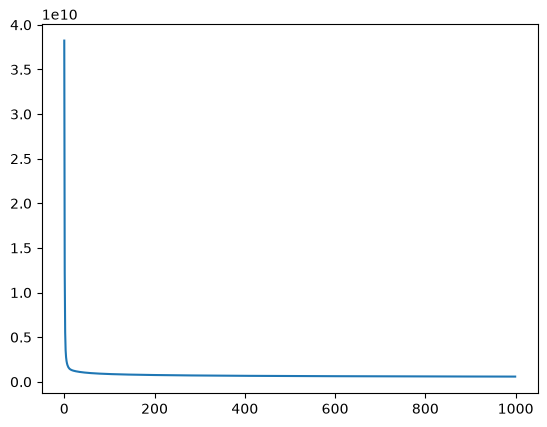

In [105]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [106]:
from sklearn.metrics import root_mean_squared_error

y_pred_train = lin.predict(X_train_preprocessed)
y_pred_val = lin.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(24184.23531714344, 42998.23954426335)

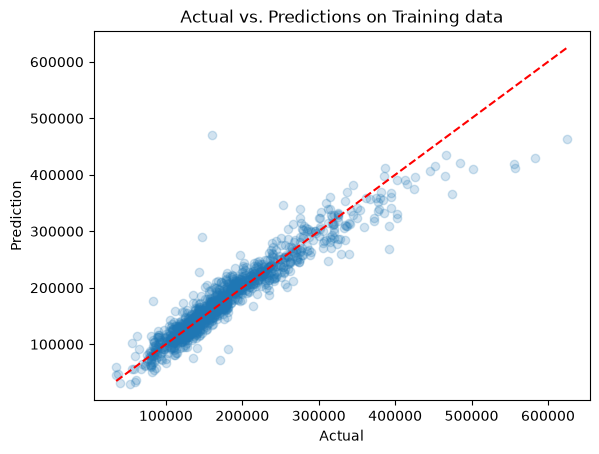

In [107]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [108]:
test_data.drop(null_pct, axis=1, inplace=True)
test_data.drop(multi_col, axis=1, inplace=True)

In [109]:
preprocessed_test_data = preprocessing.transform(test_data).toarray()

y_pred_test = lin.predict(preprocessed_test_data)

y_pred_test

array([114252.38946283, 156902.68646121, 167102.18846446, ...,
       160633.59690852, 111576.73757449, 226630.65680617], shape=(1459,))

In [110]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,114252.389463
1462,156902.686461
1463,167102.188464
1464,191619.989149
1465,193620.266424


In [111]:
output_df.to_csv('data/house_prices/submission.csv')

Kaggle Score = 0.15063

In [112]:
lin.fit(X_train_preprocessed, y_train, learning_rate=0.02, loss_function='rmse')

RMSE loss at epoch 0 = 195537.54101869764
RMSE loss at epoch 100 = 27557.311377290956
RMSE loss at epoch 200 = 25908.485081682953
RMSE loss at epoch 300 = 25070.184790176354
RMSE loss at epoch 400 = 24546.34131901826
RMSE loss at epoch 500 = 24183.649888716147
RMSE loss at epoch 600 = 23913.14613572347
RMSE loss at epoch 700 = 23699.739155420022
RMSE loss at epoch 800 = 23524.2903458857
RMSE loss at epoch 900 = 23375.702684253025
RMSE loss at epoch 1000 = 23248.343838724373


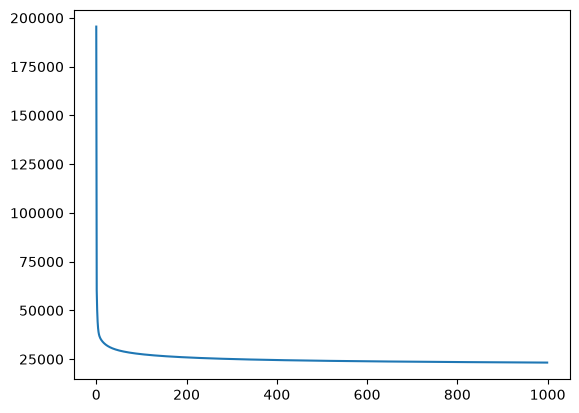

In [113]:
losses = lin.losses_

plt.plot(losses)
plt.show()

In [114]:
y_pred_train = lin.predict(X_train_preprocessed)
y_pred_val = lin.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(23247.141316302183, 42160.1086044574)

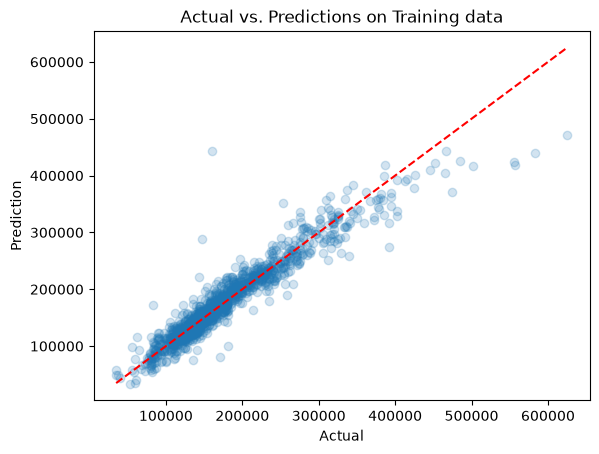

In [115]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [116]:
y_pred_test = lin.predict(preprocessed_test_data)

y_pred_test

array([115825.81140334, 152170.53069415, 165215.12265887, ...,
       158834.61078001, 108257.49081542, 221863.86259094], shape=(1459,))

In [117]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,115825.811403
1462,152170.530694
1463,165215.122659
1464,185637.366097
1465,199221.271840


In [118]:
output_df.to_csv('data/house_prices/submission2.csv')

Kaggle Score = 0.14895

In [156]:
reg.fit(X_train_preprocessed, y_train, mode='ridge', epochs=5000, loss_function='rmse')

RMSE loss at epoch 0 = 195538.42176717584
RMSE loss at epoch 100 = 23403287.5019858
RMSE loss at epoch 200 = 28029346.89915877
RMSE loss at epoch 300 = 31752037.988880273
RMSE loss at epoch 400 = 34997219.2314446
RMSE loss at epoch 500 = 37908356.03770607
RMSE loss at epoch 600 = 40553368.938731134
RMSE loss at epoch 700 = 42971995.312034965
RMSE loss at epoch 800 = 45191924.57250581
RMSE loss at epoch 900 = 47235282.08525131
RMSE loss at epoch 1000 = 49121182.97569365
RMSE loss at epoch 1100 = 50866655.00303404
RMSE loss at epoch 1200 = 52486943.72979746
RMSE loss at epoch 1300 = 53995627.12972926
RMSE loss at epoch 1400 = 55404700.880661
RMSE loss at epoch 1500 = 56724682.208012156
RMSE loss at epoch 1600 = 57964736.651105024
RMSE loss at epoch 1700 = 59132818.74721885
RMSE loss at epoch 1800 = 60235816.076140694
RMSE loss at epoch 1900 = 61279688.41821652
RMSE loss at epoch 2000 = 62269596.74796805
RMSE loss at epoch 2100 = 63210019.30164018
RMSE loss at epoch 2200 = 64104853.770051

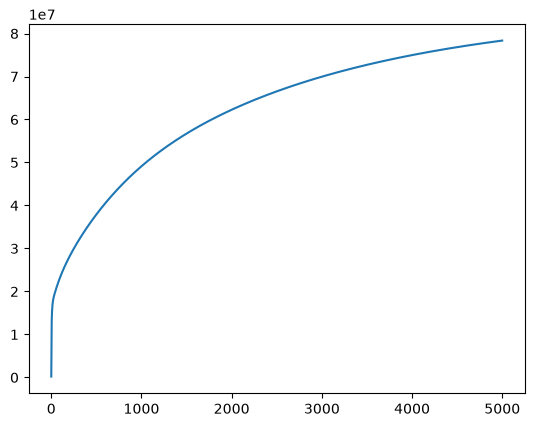

In [157]:
losses = reg.losses_

plt.plot(losses)
plt.show()

In [158]:
from sklearn.metrics import root_mean_squared_error

y_pred_train = reg.predict(X_train_preprocessed)
y_pred_val = reg.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(22935.060913860918, 41943.03038832239)

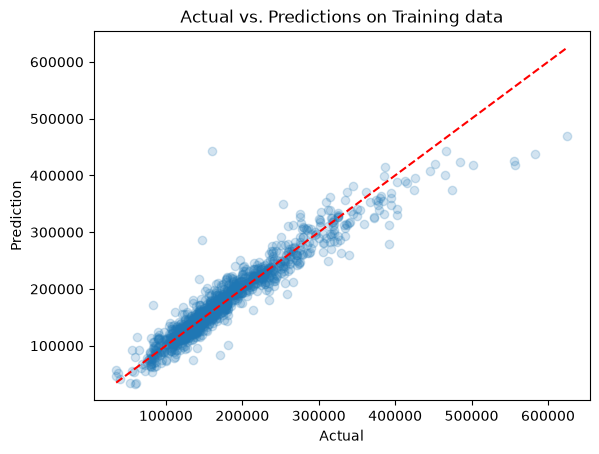

In [159]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [160]:
y_pred_test = reg.predict(preprocessed_test_data)

y_pred_test

array([116681.49412253, 154851.10727621, 166608.8011957 , ...,
       160134.34860221, 107812.88740869, 220584.49764276], shape=(1459,))

In [161]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,116681.494123
1462,154851.107276
1463,166608.801196
1464,188060.402108
1465,203062.862373


In [162]:
output_df.to_csv('data/house_prices/submission_ridge.csv')

Kaggle Score = 0.14819

In [140]:
reg.fit(X_train_preprocessed, y_train, mode='lasso', epochs=5000, loss_function='rmse')

RMSE loss at epoch 0 = 195538.85086060874
RMSE loss at epoch 100 = 34076.951991948714
RMSE loss at epoch 200 = 32787.22050122806
RMSE loss at epoch 300 = 32311.78056016558
RMSE loss at epoch 400 = 32109.26554647023
RMSE loss at epoch 500 = 32022.66297383394
RMSE loss at epoch 600 = 31996.89827196812
RMSE loss at epoch 700 = 32006.603846045546
RMSE loss at epoch 800 = 32045.820274698504
RMSE loss at epoch 900 = 32106.450880026874
RMSE loss at epoch 1000 = 32175.64990474004
RMSE loss at epoch 1100 = 32251.75726320373
RMSE loss at epoch 1200 = 32330.60189819622
RMSE loss at epoch 1300 = 32412.19016591426
RMSE loss at epoch 1400 = 32493.884587672343
RMSE loss at epoch 1500 = 32573.656110462736
RMSE loss at epoch 1600 = 32653.747097583495
RMSE loss at epoch 1700 = 32733.687680755225
RMSE loss at epoch 1800 = 32812.05914693848
RMSE loss at epoch 1900 = 32888.33611040155
RMSE loss at epoch 2000 = 32963.042648758594
RMSE loss at epoch 2100 = 33035.68558988741
RMSE loss at epoch 2200 = 33106.34

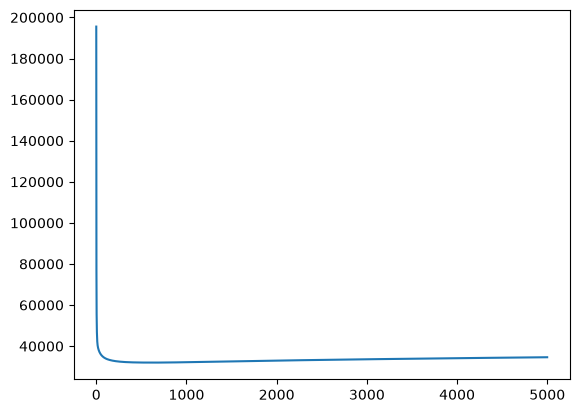

In [141]:
losses = reg.losses_

plt.plot(losses)
plt.show()

In [142]:
from sklearn.metrics import root_mean_squared_error

y_pred_train = reg.predict(X_train_preprocessed)
y_pred_val = reg.predict(X_val_preprocessed)

root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_val, y_pred_val)

(22284.43752231203, 41416.75720412776)

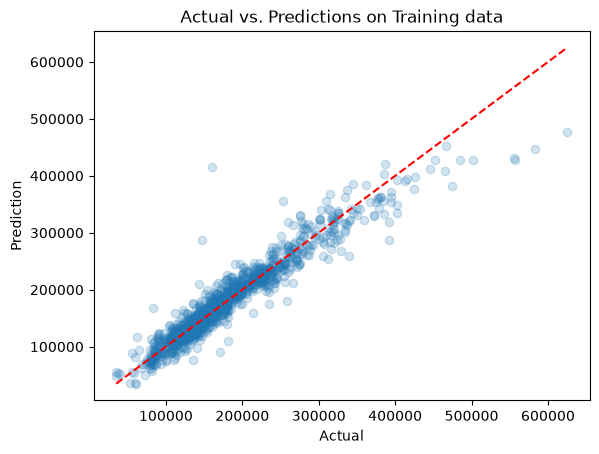

In [143]:
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.title('Actual vs. Predictions on Training data')

plt.show()

In [144]:
y_pred_test = reg.predict(preprocessed_test_data)

y_pred_test

array([117258.66770427, 152342.98968745, 165246.7674683 , ...,
       157991.61788043, 104803.52386263, 216041.0486158 ], shape=(1459,))

In [145]:
output_df = pd.DataFrame(
    y_pred_test,
    index=test_data.index,
    columns=['SalePrice']
)

output_df.head()

,SalePrice
Id,
1461,117258.667704
1462,152342.989687
1463,165246.767468
1464,184101.096479
1465,210817.515715


In [146]:
output_df.to_csv('data/house_prices/submission_lasso.csv')

Kaggle Score = 0.15197